# LNA Noise Figure Analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from rfmodel.core.config import load_yaml
from rfmodel.core.signal import Signal
from rfmodel.core.pipeline_builder import pipeline_from_config
from rfmodel.core.units import w_to_dbm, dbm_to_w
from rfmodel.meas.spectrum_analyser import spectrum_analyser
from rfmodel.plot_utils.spectrum_plot import plot_top_spectrum
from scipy.signal import hilbert
import rfmodel.rf.registry
cfg = load_yaml(r".\pipeline_LNA_demo.yaml")
pipe = pipeline_from_config(cfg)


In [2]:
fs = 5_000_000
fc = 1e6
f0 = 50_000
dur = 0.2
t = np.arange(0, dur, 1/fs)

Pin_dbm = -40.0
Pin_W = dbm_to_w(Pin_dbm)

A = np.sqrt(Pin_W)  # for complex tone: mean(|A*e^{jωt}|^2)=A^2=Pin_W
x_in = A * np.exp(1j*2*np.pi*f0*t)

sig_in = Signal(x=x_in, fs_hz=fs, fc_hz=fc, meta={"Pin_dbm": Pin_dbm})

sig_out, _ = pipe.run(sig_in)

G = np.mean(np.abs(sig_out.x)**2) / np.mean(np.abs(sig_in.x)**2)
G_db = 10*np.log10(G)
print("Gain (dB):", G_db)

Gain (dB): 9.99998330321205


## Evaluating Input and Output Noise Power

In [3]:
kB = 1.380649e-23
T = 290.0
B = fs/2.0
dur = 0.2
N = int(fs*dur)

Pn_in = kB*T*B
sigma = np.sqrt(Pn_in/2)

rng = np.random.default_rng(0)
x_in = sigma*(rng.normal(size=N) + 1j*rng.normal(size=N))

sig_in = Signal(x=x_in, fs_hz=fs, fc_hz=fc, meta={})

sig_out, taps = pipe.run(sig_in, taps=["lna1"])
x_out = taps["lna1"].x

Pnout = np.mean(np.abs(x_out)**2)

print("Output noise power (W):", Pnout)
print("Output noise power (dBm):", 10*np.log10(Pnout/1e-3))

Output noise power (W): 3.1652158101131154e-13
Output noise power (dBm): -94.99596673657364


## Deriving Noise Figure and Plotting Noise Spectrum

In [4]:
F = Pnout / (G * Pn_in)
NF_db = 10*np.log10(F)

print("Noise Figure (dB):", NF_db)

Noise Figure (dB): 4.9998370677220505


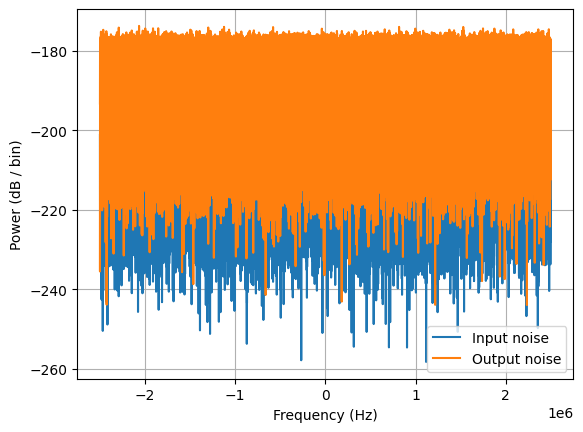

In [5]:
S_in, freq = spectrum_analyser(x_in, fs)
S_out, _ = spectrum_analyser(x_out, fs)

S_in_db = 10*np.log10(np.maximum(S_in, 1e-30))
S_out_db = 10*np.log10(np.maximum(S_out, 1e-30))

plt.figure()
plt.plot(freq, S_in_db, label="Input noise")
plt.plot(freq, S_out_db, label="Output noise")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (dB / bin)")
plt.legend()
plt.grid(True)
plt.show()